# 0.1 Task

Change the optimiser to Adam and run again the experiment. Report accuracy on test set.

**Adam Optimizer:** Best test accuracy = 0.6712

In [1]:
import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms


BATCH_SIZE = 64
LEARNING_RATE = 1e-4
NUM_EPOCHS = 10
NUM_CLASSES = 10
LOG_DIR = "runs/cifar10_adam"
MODEL_DIR = "saved_models"
MODEL_PATH = os.path.join(MODEL_DIR, "cifar10_adam.pth")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class SimpleCNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(256, NUM_CLASSES),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x


def train_one_epoch(model, loader, criterion, optimizer, epoch, writer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        global_step = epoch * len(loader) + batch_idx
        writer.add_scalar("Batch/Loss", loss.item(), global_step)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def main():
    print(f"Using device: {DEVICE}")

    Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)
    Path(LOG_DIR).mkdir(parents=True, exist_ok=True)

    transform_train = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    train_dataset = datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=transform_train,
    )

    test_dataset = datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=transform_test,
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
    )

    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
    )

    model = SimpleCNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    writer = SummaryWriter(log_dir=LOG_DIR)

    best_test_acc = 0.0

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, epoch, writer
        )
        test_loss, test_acc = evaluate(model, test_loader, criterion)

        writer.add_scalar("Epoch/Train_Loss", train_loss, epoch)
        writer.add_scalar("Epoch/Train_Accuracy", train_acc, epoch)
        writer.add_scalar("Epoch/Test_Loss", test_loss, epoch)
        writer.add_scalar("Epoch/Test_Accuracy", test_acc, epoch)

        print(
            f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
        )

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(model.state_dict(), MODEL_PATH)

    writer.flush()
    writer.close()

    print(f"\nBest test accuracy: {best_test_acc:.4f}")
    print(f"Model saved to: {MODEL_PATH}")
    print(f"TensorBoard logs saved to: {LOG_DIR}")
    print("\nRun TensorBoard with:")
    print(f"tensorboard --logdir {LOG_DIR}")


if __name__ == "__main__":
    main()

Using device: cpu
Epoch [1/10] | Train Loss: 1.6901 | Train Acc: 0.3916 | Test Loss: 1.4606 | Test Acc: 0.4731
Epoch [2/10] | Train Loss: 1.3905 | Train Acc: 0.5015 | Test Loss: 1.3377 | Test Acc: 0.5228
Epoch [3/10] | Train Loss: 1.2774 | Train Acc: 0.5462 | Test Loss: 1.2353 | Test Acc: 0.5585
Epoch [4/10] | Train Loss: 1.1923 | Train Acc: 0.5778 | Test Loss: 1.1564 | Test Acc: 0.5935
Epoch [5/10] | Train Loss: 1.1168 | Train Acc: 0.6074 | Test Loss: 1.1307 | Test Acc: 0.6001
Epoch [6/10] | Train Loss: 1.0557 | Train Acc: 0.6289 | Test Loss: 1.0444 | Test Acc: 0.6318
Epoch [7/10] | Train Loss: 1.0038 | Train Acc: 0.6467 | Test Loss: 1.0148 | Test Acc: 0.6428
Epoch [8/10] | Train Loss: 0.9576 | Train Acc: 0.6657 | Test Loss: 0.9645 | Test Acc: 0.6568
Epoch [9/10] | Train Loss: 0.9146 | Train Acc: 0.6820 | Test Loss: 0.9723 | Test Acc: 0.6586
Epoch [10/10] | Train Loss: 0.8778 | Train Acc: 0.6936 | Test Loss: 0.9351 | Test Acc: 0.6712

Best test accuracy: 0.6712
Model saved to: saved_m

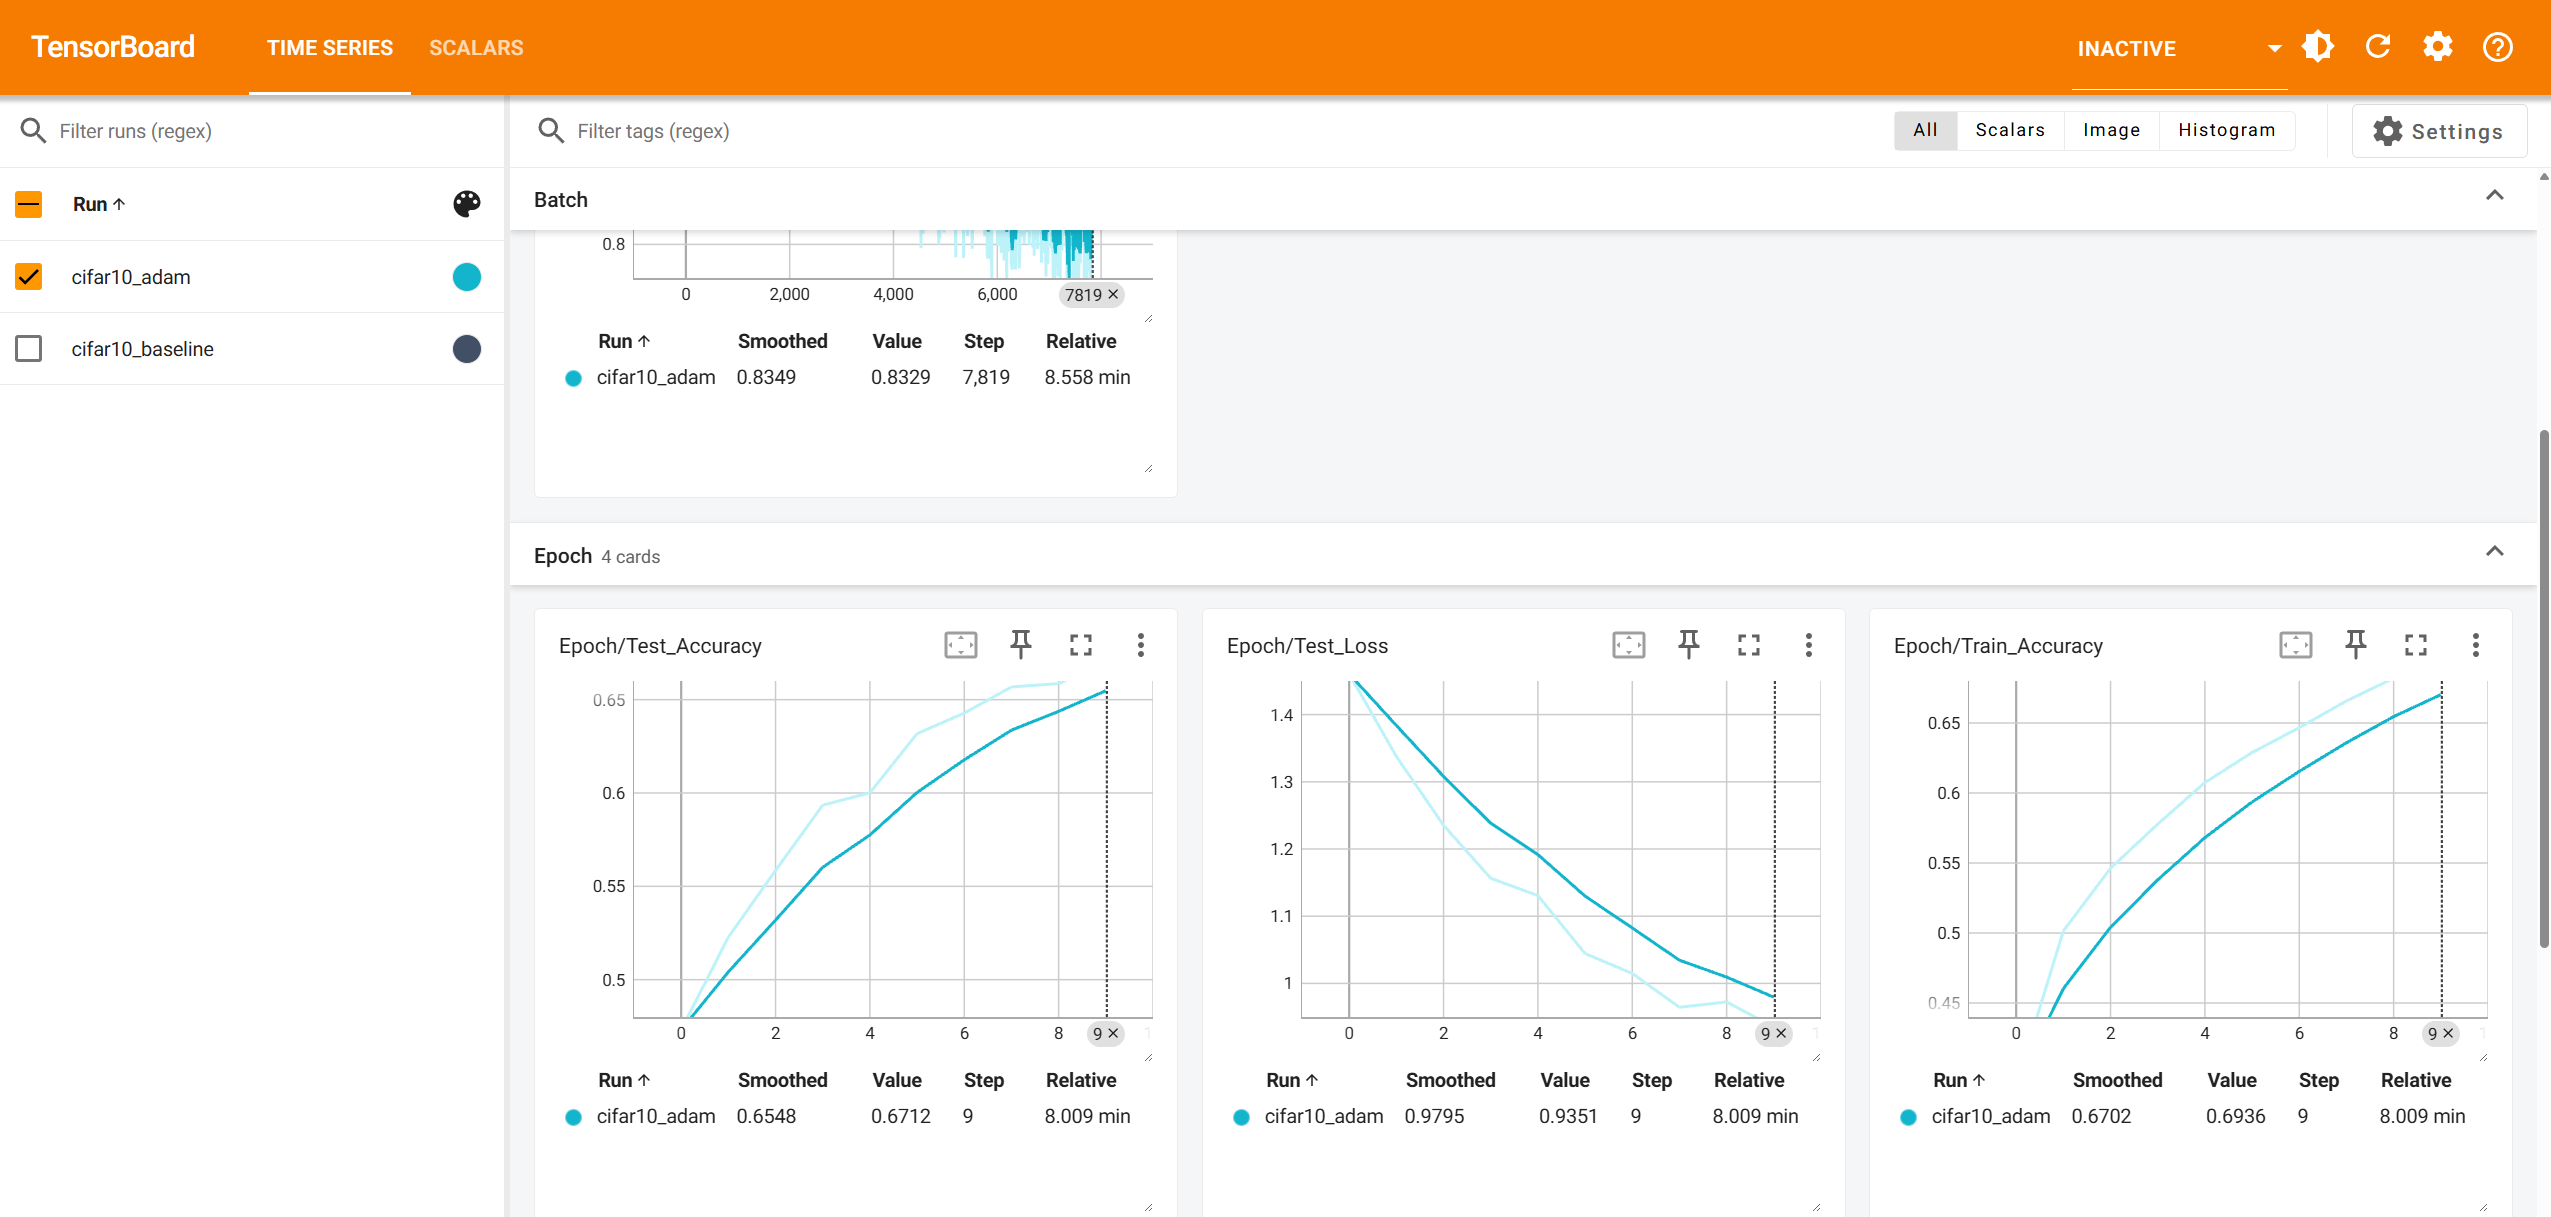
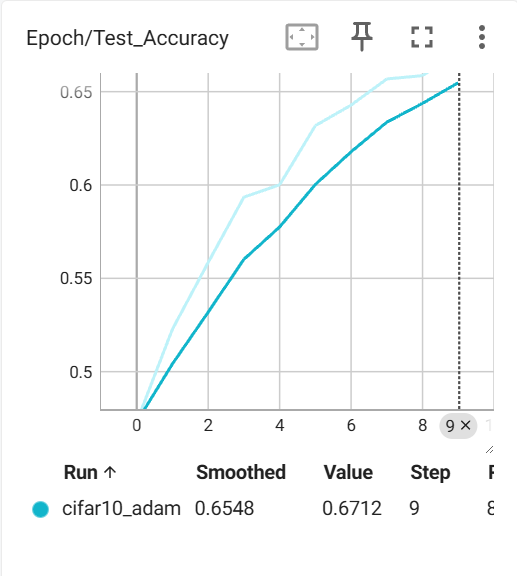
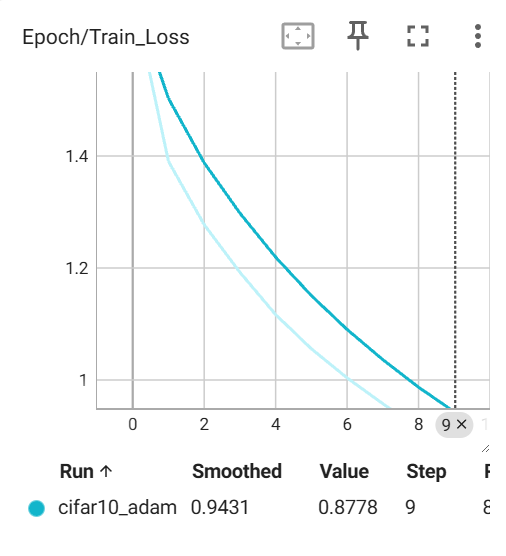